# [1] Encoding

In [303]:
!pip install scikit.learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.1.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [304]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

In [305]:
data = {
    '고객ID': [101, 102, 103, 104, 105],
    'VIP등급': ['Silver', 'Bronze', 'Gold', 'Silver', 'Bronze']
}
df = pd.DataFrame(data)

In [306]:
df

,고객ID,VIP등급
0,101,Silver
1,102,Bronze
2,103,Gold
3,104,Silver
4,105,Bronze


## (1) 순서가 있는 범주형 데이터
### 1) ordinalencoder

In [307]:
grade_categories = ['Bronze', 'Silver', 'Gold']

In [308]:
encoder = OrdinalEncoder(categories=[grade_categories])
encoder

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['Bronze', 'Silver', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


In [309]:
# fit <-> fit_transform 차이가 뭐지?
# fit_transform 은 학습 + 변환을 같이함
# 2차원 배열 이기에 겹괄호 사용
df['VIP등급_숫자'] = encoder.fit_transform(df[['VIP등급']])

In [310]:
print(df)

   고객ID   VIP등급  VIP등급_숫자
0   101  Silver       1.0
1   102  Bronze       0.0
2   103    Gold       2.0
3   104  Silver       1.0
4   105  Bronze       0.0


### 2) Label Encoding

> Label = 정답지

In [311]:
from sklearn.preprocessing import LabelEncoder

In [312]:
encoder = LabelEncoder()
encoder

LabelEncoder()

In [313]:
df['VIP등급_라벨'] = encoder.fit_transform(df['VIP등급'])
df

,고객ID,VIP등급,VIP등급_숫자,VIP등급_라벨
0,101,Silver,1.0,2
1,102,Bronze,0.0,0
2,103,Gold,2.0,1
3,104,Silver,1.0,2
4,105,Bronze,0.0,0


## (2) 순서가 없는 범주형 데이터

### 3) One-hot Encoding

In [314]:
data = {
    '고객ID': [1, 2, 3, 4],
    '성별': ['남', '여', '여', '남'],
    '지역': ['서울', '부산', '제주', '서울']
}
df = pd.DataFrame(data)

In [315]:
# get_dummies = boll lean 형태 반환
# drop_first = 중복 행 제거, bool 형태로 모든 컬럼 값 구분 가능
df_encoded = pd.get_dummies(df, columns=['성별','지역'], drop_first=True)
df_encoded

,고객ID,성별_여,지역_서울,지역_제주
0,1,False,True,False
1,2,True,False,False
2,3,True,False,True
3,4,False,True,False


# [2] Scaling

> Scaling: 숫자 데이터의 범위를 통합하는 작업

In [316]:
data = {
    '나이': [25, 30, 45, 20, 35, 50],
    '연봉': [3000, 5000, 8000, 2500, 6000, 9500]
}
df = pd.DataFrame(data)

In [317]:
df

,나이,연봉
0,25,3000
1,30,5000
2,45,8000
3,20,2500
4,35,6000
5,50,9500


### 1) standardscaler : 표준화

In [318]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [319]:
X_train, X_test = train_test_split(df, test_size =0.3, random_state=42)
print(X_train)
print(X_test)

   나이    연봉
5  50  9500
2  45  8000
4  35  6000
3  20  2500
   나이    연봉
0  25  3000
1  30  5000


In [320]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
scaler

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [321]:
scaler.fit(X_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [322]:
X_train_scaled

array([[ 1.09108945,  1.14415511],
       [ 0.65465367,  0.57207755],
       [-0.21821789, -0.19069252],
       [-1.52752523, -1.52554014]])

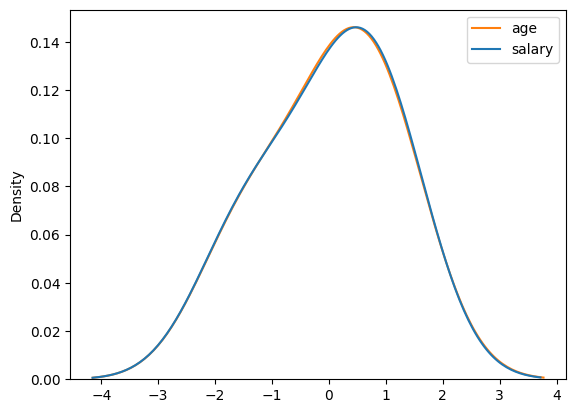

In [323]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(X_train_scaled)
plt.legend(['age','salary'])

### 2) MinMaxSclaer : 정규화

가장 큰값 :1
가장 작은 값:0
에 따른 비율 값으로 제한, 하지만 변환된 값의 범위가 매우 좁아지는 문제

In [324]:
from sklearn.preprocessing import MinMaxScaler

In [325]:
sclaer = MinMaxScaler()
X_train_scaled = sclaer.fit_transform(X_train)
X_test_scaled = sclaer.transform(X_test)

In [326]:
X_train_scaled

array([[1.        , 1.        ],
       [0.83333333, 0.78571429],
       [0.5       , 0.5       ],
       [0.        , 0.        ]])

In [327]:
X_test_scaled

array([[0.16666667, 0.07142857],
       [0.33333333, 0.35714286]])

### 3) 이상치에 강함 : RobustSclaer
(x-median) / IQR : 중앙값을 빼고 IQR로 나누기에 이상치에 강함

In [328]:
from sklearn.preprocessing import RobustScaler

In [329]:
sclaer = RobustScaler()
X_train_scaled = sclaer.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [330]:
sclaer

,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"unit_variance unit_variance: bool, default=FalseIf `True`, scale data so that normally distributed features have avariance of 1. In general, if the difference between the x-values of`q_max` and `q_min` for a standard normal distribution is greaterthan 1, the dataset will be scaled down. If less than 1, the datasetwill be scaled up... versionadded:: 0.24",False


In [331]:
X_train_scaled

array([[ 0.66666667,  0.76923077],
       [ 0.33333333,  0.30769231],
       [-0.33333333, -0.30769231],
       [-1.33333333, -1.38461538]])

In [332]:
X_test_scaled

array([[-1.09108945, -1.33484762],
       [-0.65465367, -0.57207755]])

In [333]:
X_test_new = pd.DataFrame({'나이':[100,20,6],
                           '연봉': [100000,1200,0]})

In [334]:
scaler.transform(X_test_new)

array([[ 5.45544726, 35.65950084],
       [-1.52752523, -2.02134069],
       [-2.74954542, -2.47900273]])

```
StandardScaler
평균=0, 표준편차=1
보통
가장 일반적 (기본값으로 추천)
MinMaxScaler
0~1 범위로 압축
약함
값의 범위를 명확히 제한할 때
RobustScaler
중앙값, IQR 사용
강함
이상치가 많은 데이터
```

> 어떤 스케일러를 써야 할지 모르겠다면?
→ 일단 StandardScaler를 쓰세요. 대부분의 상황에서 잘 작동합니다. 이상치가 심하면 RobustScaler를 시도해 보세요.

> fit은 train에만, transform은 train/test 모두에

> 순서 있으면 OrdinalEncoder, 없으면 One-Hot(get_dummies)

# [3] 실습 - Titanic 생존 예측 데이터셋

In [335]:
import pandas as pd
import seaborn as sns

In [336]:
df = sns.load_dataset('titanic')

In [337]:
df =df[['survived','pclass','sex','age','fare','embarked']]
df.head()

,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [338]:
print(f"데이터 크기: {df.shape}")
print(f"결측치 확인: {df.isnull().sum()}")
print(f"데이터 타입: {df.dtypes}")

데이터 크기: (891, 6)
결측치 확인: survived      0
pclass        0
sex           0
age         177
fare          0
embarked      2
dtype: int64
데이터 타입: survived      int64
pclass        int64
sex          object
age         float64
fare        float64
embarked     object
dtype: object


In [339]:
# age: 숫자형 → 중앙값(median)으로 채우기
df['age'] = df['age'].fillna(df['age'].median())
# embarked: 범주형 → 최빈값(mode)으로 채우기
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
# 결측치가 사라졌는지 확인
print(df.isnull().sum())

survived    0
pclass      0
sex         0
age         0
fare        0
embarked    0
dtype: int64


In [340]:
# sex, embarked: 순서가 없는 범주 → One-Hot Encoding
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)
# 결과 확인
print(df.columns.tolist())
print(df.head())

['survived', 'pclass', 'age', 'fare', 'sex_male', 'embarked_Q', 'embarked_S']
   survived  pclass   age     fare  sex_male  embarked_Q  embarked_S
0         0       3  22.0   7.2500      True       False        True
1         1       1  38.0  71.2833     False       False       False
2         1       3  26.0   7.9250     False       False        True
3         1       1  35.0  53.1000     False       False        True
4         0       3  35.0   8.0500      True       False        True


In [341]:
from sklearn.model_selection import train_test_split

In [343]:
# X: 특성, y: 타겟(생존 여부)
X = df.drop('survived', axis=1)
y = df['survived']
# 80:20 분할, 클래스 비율 유지
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (712, 6), Test: (179, 6)


In [345]:
from sklearn.preprocessing import StandardScaler

In [346]:
scaler = StandardScaler()

In [347]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"스케일링 전 age 범위: {X_train['age'].min():.0f} ~ {X_train['age'].max():.0f}")
print(f"스케일링 후 age 범위: {X_train_scaled[:, 1].min():.2f} ~ {X_train_scaled[:, 1].max():.2f}")

스케일링 전 age 범위: 0 ~ 80
스케일링 후 age 범위: -2.23 ~ 3.88


In [348]:
from sklearn.tree import DecisionTreeClassifier

In [349]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
# Train vs Test 점수 비교 → 과적합 확인!
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)
print(f"Train 정확도: {train_score:.2f}")
print(f"Test 정확도:  {test_score:.2f}")
print(f"차이: {train_score - test_score:.2f}")

Train 정확도: 0.98
Test 정확도:  0.83
차이: 0.15


In [350]:
depths = [2, 3, 5, 10, None]  # None = 제한 없음
for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_sc = model.score(X_train_scaled, y_train)
    test_sc = model.score(X_test_scaled, y_test)
    print(f"max_depth={str(depth):>4} → Train: {train_sc:.2f}, Test: {test_sc:.2f}, 차이: {train_sc - test_sc:.2f}")

max_depth=   2 → Train: 0.80, Test: 0.76, 차이: 0.04
max_depth=   3 → Train: 0.83, Test: 0.78, 차이: 0.05
max_depth=   5 → Train: 0.87, Test: 0.77, 차이: 0.09
max_depth=  10 → Train: 0.94, Test: 0.82, 차이: 0.13
max_depth=None → Train: 0.98, Test: 0.83, 차이: 0.15
